## Computer Vision(CV) model workflow for DETR-ResNet50

Copyright (c) 2025 Qualcomm Innovation Center, Inc. All rights reserved.<br>
SPDX-License-Identifier: BSD-3-Clause-Clear

### Developer workflow

Please refer https://quic.github.io/cloud-ai-sdk-pages/latest/Getting-Started/Inference-Workflow/ for more details.

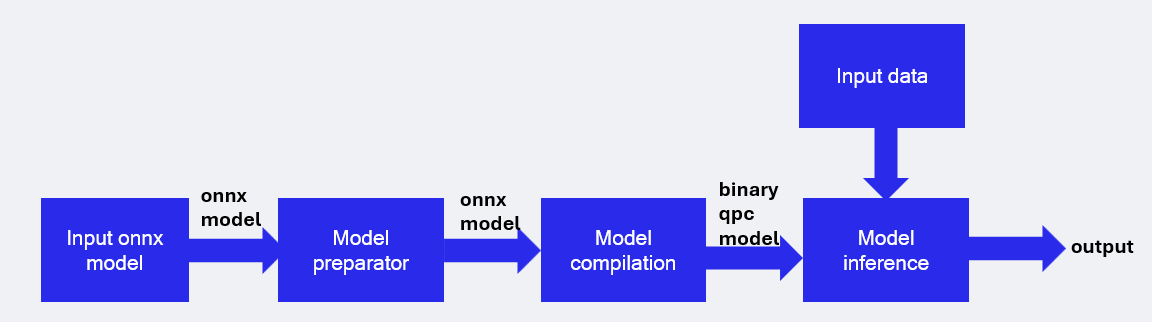

### Import libraries

In [1]:
import os
import sys
import torch
import numpy as np
import onnx
from onnx import numpy_helper
import time
from PIL import Image
import requests
import torchvision.transforms as T
import matplotlib.pyplot as plt


### Support functions

In [2]:
# clips the fp32 values to the range of fp16
def fix_onnx_fp16(gen_models_path,  model_base_name):
    print("Fixing ONNX to FP16", flush=True)
    finfo = np.finfo(np.float16)
    fp16_max = finfo.max
    fp16_min = finfo.min
    model = onnx.load(f"{gen_models_path}/{model_base_name}.onnx")
    fp16_fix = False
    for tensor in onnx.external_data_helper._get_all_tensors(model):
        nptensor = numpy_helper.to_array(tensor, gen_models_path)
        if nptensor.dtype == np.float32 and (np.any(nptensor > fp16_max) or np.any(nptensor < fp16_min)):
            nptensor = np.clip(nptensor, fp16_min, fp16_max)
            new_tensor = numpy_helper.from_array(nptensor, tensor.name)
            tensor.CopyFrom(new_tensor)
            fp16_fix = True
    onnx.load_external_data_for_model(model, gen_models_path)
    size_gb = model.ByteSize() / 1073741824
    if fp16_fix:
        # Save FP16 model
        print("Found constants out of FP16 range, clipped to FP16 range", flush=True)
        # model_base_name += "_fixed_for_fp16"
        if size_gb <= 2:
            onnx.save(model,
                      f=f"{gen_models_path}/{model_base_name}.onnx")
        else:
            onnx.save(model,
                      f=f"{gen_models_path}/{model_base_name}.onnx",
                      save_as_external_data=True,
                      all_tensors_to_one_file=True,
                      location=f"{model_base_name}.onnx.data",
                      convert_attribute=True)
        print(f"Saving modified onnx file at {gen_models_path}/{model_base_name}.onnx", flush=True)
    return model_base_name

# executes the command and writes it down in the command.txt. The first time, mode is 'w', then 'a' (append)
def execute(cmd_elements, write_to_file, mode):
    cmd_str = ' '.join(str(x) for x in cmd_elements)
    os.system(cmd_str)
    with open(write_to_file, mode) as file:
        file.write(cmd_str + "\n\n")

# generates the yaml file as per requirement of the qaic_model_preparator.py
def gen_yaml(model_base_name, batch_size, image_height,image_width):
    onnx_model = "./" + model_base_name+'.onnx'
    model = onnx.load(onnx_model)
    for inp in model.graph.input:
        name = str(inp.name)
    yaml_file=f'''
MODEL:
    INFO:
        DESCRIPTION: "OBJECT DETECTION"
        MODEL_TYPE: UNKNOWN
        MODEL_PATH: {onnx_model}
        INPUT_INFO: [["{name}", [{batch_size}, 3, {image_height}, {image_width}]]] 
        EXPORT_TYPE: ONNX
        DYNAMIC_INFO:  [] 
        VALIDATE: False
        WORKSPACE: WORKSPACE
        VERBOSE: INFO #INFO, DEBUG, WARNING. TRACE

    PRE_POST_HANDLE:
        ANCHOR_BIN_FILE: None
        POST_PLUGIN: None
        PRE_PLUGIN: True
        NMS_PARAMS:
            MAX_OUTPUT_SIZE_PER_CLASS: None
            MAX_TOTAL_SIZE: None
            IOU_THRESHOLD: None
            SCORE_THRESHOLD: None
            CLIP_BOXES: None
            PAD_PER_CLASS: None

    '''
    with open(f'./model.yaml', 'w') as file: file.write(yaml_file)

# plot results
def plot_results(pil_img, prob, boxes):
    plt.figure(figsize=(16,10))
    plt.imshow(pil_img)
    ax = plt.gca()
    colors = COLORS * 100
    for p, (xmin, ymin, xmax, ymax), c in zip(prob, boxes.tolist(), colors):
        ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                   fill=False, color=c, linewidth=3))
        cl = p.argmax()
        text = f'{CLASSES[cl]}: {p[cl]:0.2f}'
        ax.text(xmin, ymin, text, fontsize=15,bbox=dict(facecolor='yellow', alpha=0.5))
    plt.axis('off')
    plt.show()

# post-processing for bounding box
def box_cxcywh_to_xyxy(x):
    x_c, y_c, w, h = x.unbind(1)
    b = [(x_c - 0.5 * w), (y_c - 0.5 * h),
         (x_c + 0.5 * w), (y_c + 0.5 * h)]
    return torch.stack(b, dim=1)

def rescale_bboxes(out_bbox, size):
    img_w, img_h = size
    b = box_cxcywh_to_xyxy(out_bbox)
    b = b * torch.tensor([img_w, img_h, img_w, img_h], dtype=torch.float32)
    return b

### onnx model preparation

In [3]:
model_base_name="detr_resnet50"
batch_size=1
image_width=1333
image_height=750

model = torch.hub.load('facebookresearch/detr', 'detr_resnet50', pretrained=True)
model.eval()
dummy_input = torch.randn(batch_size, 3, image_height, image_width)
onnx_model_path = model_base_name+'.onnx'
torch.onnx.export(model, dummy_input, onnx_model_path, opset_version=14, input_names=['pixel_values'], output_names=['pred_logits', 'pred_boxes'])

Using cache found in /root/.cache/torch/hub/facebookresearch_detr_main
/usr/local/lib/python3.8/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/root/.cache/torch/hub/facebookresearch_detr_main/util/misc.py:338: TracerWarning: Iterating over a tensor might cause the trace to be incorrect. Passing a tensor of different shape won't change the number of iterations executed (and might lead to errors or silently give incorrect results).
  max_size_i = t

### Model preparator

Please refer https://quic.github.io/cloud-ai-sdk-pages/latest/Getting-Started/Inference-Workflow/Export-the-model/Prepare-the-model/ for more details.

In [4]:
# generate model.yaml file required for model preparator tool
gen_yaml(model_base_name, batch_size,image_height,image_width)        

In [5]:
# run model preparator tool
os.system('echo y |  /opt/qti-aic/dev/python/qaic-env/bin/python /opt/qti-aic/tools/qaic-pytools/qaic-model-preparator.py --config model.yaml')

2025-04-28 06:04:36.284012: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-28 06:04:36.345918: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-28 06:04:36.346351: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-28 06:04:37.201317: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2025-04-28 06:04:38.361 | WARNING  | __main__:prepare_work_dir:40 - Directory WORKSPACE will be deleted if already exists. Take backup before execution.
2025-04-28 06:04:38.395 | INFO     | __main__:main:79 - QAic Model Preparator Tool


Do you want to start execution? (yes/no) :

2025-04-28 06:04:38.604 | INFO     | qaic_pytools.qmodel.backend.onnx.model:native_checker:753 - Graph checker passed successfully.
2025-04-28 06:04:38.774 | INFO     | qaic_pytools.qmodel.preparator.preparator:__prepare_onnx:277 - Native Checker on the input model is successful
2025-04-28 06:04:38.774 | INFO     | qaic_pytools.qmodel.preparator.preparator:__prepare_onnx:281 - Native Checker on the model is successful
2025-04-28 06:04:39.750 | INFO     | qaic_pytools.qmodel.preparator.preparator:__prepare_onnx:292 - Internal Checker (Ort) on the model is successful.
2025-04-28 06:04:42.047 | INFO     | qaic_pytools.qmodel.preparator.preparator:__prepare_onnx:308 - Native Shape Inference Passed successfully
2025-04-28 06:05:01.529 | INFO     | qaic_pytools.qmodel.backend.onnx.optimizer:optimize_by_simplifier:131 - Simplified model validation is successfully
2025-04-28 06:05:02.468 | INFO     | qaic_pytools.qmodel.preparator.preparator:__prepare_onnx:358 - Model Optimization (Simplificat

0

### Model compilation

Please refer https://quic.github.io/cloud-ai-sdk-pages/latest/Getting-Started/Inference-Workflow/model-compilation/Compile-the-Model/ for more details.

In [6]:
MODEL_FOLDER="./WORKSPACE"
MODEL_BASE_NAME=model_base_name + "_preparator_aic100"

In [7]:
DEVICE_ID = 0 # device id(QID) in which we want to run the model
CORES     = 10 # number of cores with which model need to be compiled
OLS       = 1
MOS       = 1
EXTRA     = ''

MOTIF = f"B{batch_size}-C{CORES}-OLS{OLS}"
if MOS != '': MOTIF = MOTIF + f"-MOS{MOS}"
MOTIF = MOTIF.replace(' ','')

In [8]:
# Fixing for fp16
MODEL_BASE_NAME = fix_onnx_fp16(MODEL_FOLDER, MODEL_BASE_NAME)
MODEL = f"{MODEL_FOLDER}/{MODEL_BASE_NAME}.onnx"

execute ([""], f"commands-{MOTIF}.txt", 'w')

print("\n\n*************************************************************************************", flush=True)
print(f"Compiling for BATCH_SIZE {batch_size} & for {CORES} AIC100_CORES", flush=True)
print("*************************************************************************************\n\n", flush=True)

# Compile for fp16
execute(["rm", "-rf", f"compiled-bin-fp16-{MOTIF}"], f"commands-{MOTIF}.txt", 'a')
cmd_elements = ["/opt/qti-aic/exec/qaic-exec",
                f"-m={MODEL}",
                f"-onnx-define-symbol=batch_size,{batch_size}",
                f"-aic-hw",
                f"-aic-hw-version=2.0",
                f"-aic-num-cores={CORES}",
                f"-ols={OLS}",
                f"-convert-to-fp16",
                f"-compile-only",
                f"-aic-binary-dir=./compiled-bin-fp16-{MOTIF}",
                f"-stats-batchsize={batch_size}",
                f"{EXTRA}"
                ]
# if MOS.replace(' ','') != '':
cmd_elements.extend([f"-mos={MOS}"])
execute(cmd_elements, f"commands-{MOTIF}.txt", 'a')

Fixing ONNX to FP16


*************************************************************************************
Compiling for BATCH_SIZE 1 & for 10 AIC100_CORES
*************************************************************************************


Reading ONNX Model from ./WORKSPACE/detr_resnet50_preparator_aic100.onnx
Compile started ............... 
Compiling model with FP16 precision.


Generated binary is present at ./compiled-bin-fp16-B1-C10-OLS1-MOS1


### Model inference

Please refer https://quic.github.io/cloud-ai-sdk-pages/latest/Python-API/qaic/qaic/ for more details.

In [9]:
sys.path.append('/opt/qti-aic/examples/apps/qaic-python-sdk/qaic')
import qaic

##### Model inference with random input

In [10]:
qpc_path=f"./compiled-bin-fp16-{MOTIF}" + "/programqpc.bin" #binary qpc model path 
sess = qaic.Session(model_path=qpc_path,dev_id=DEVICE_ID) #start a session with binary model path

In [11]:
# Generate a random input
input_data=np.random.rand(batch_size, 3, image_height, image_width)

In [12]:
input_dict = {'pixel_values': input_data}
output = sess.run(input_dict) # run an inference

In [ ]:
output

##### Model inference with actual input image

In [14]:
qpc_path=f"./compiled-bin-fp16-{MOTIF}" + "/programqpc.bin" #binary qpc model path 
sess = qaic.Session(model_path=qpc_path,dev_id=DEVICE_ID) #start a session with binary model path

In [15]:
# download and load input image
url = 'http://images.cocodataset.org/test2017/000000003900.jpg'
im = Image.open(requests.get(url, stream=True).raw)

In [16]:
# colors for visualization
COLORS = [[0.000, 0.447, 0.741], [0.850, 0.325, 0.098], [0.929, 0.694, 0.125],
          [0.494, 0.184, 0.556], [0.466, 0.674, 0.188], [0.301, 0.745, 0.933]]
# COCO classes
CLASSES = [
    'N/A', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A',
    'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse',
    'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack',
    'umbrella', 'N/A', 'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
    'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove',
    'skateboard', 'surfboard', 'tennis racket', 'bottle', 'N/A', 'wine glass',
    'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich',
    'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake',
    'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A',
    'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A',
    'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier',
    'toothbrush'
]

In [17]:
# pre processing steps
transform = T.Compose([
    T.Resize((750,1333)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

img = transform(im).unsqueeze(0)
input_dict["pixel_values"] = img.numpy().astype(np.float32)

In [18]:
# run an inference
outputs = sess.run(input_dict)

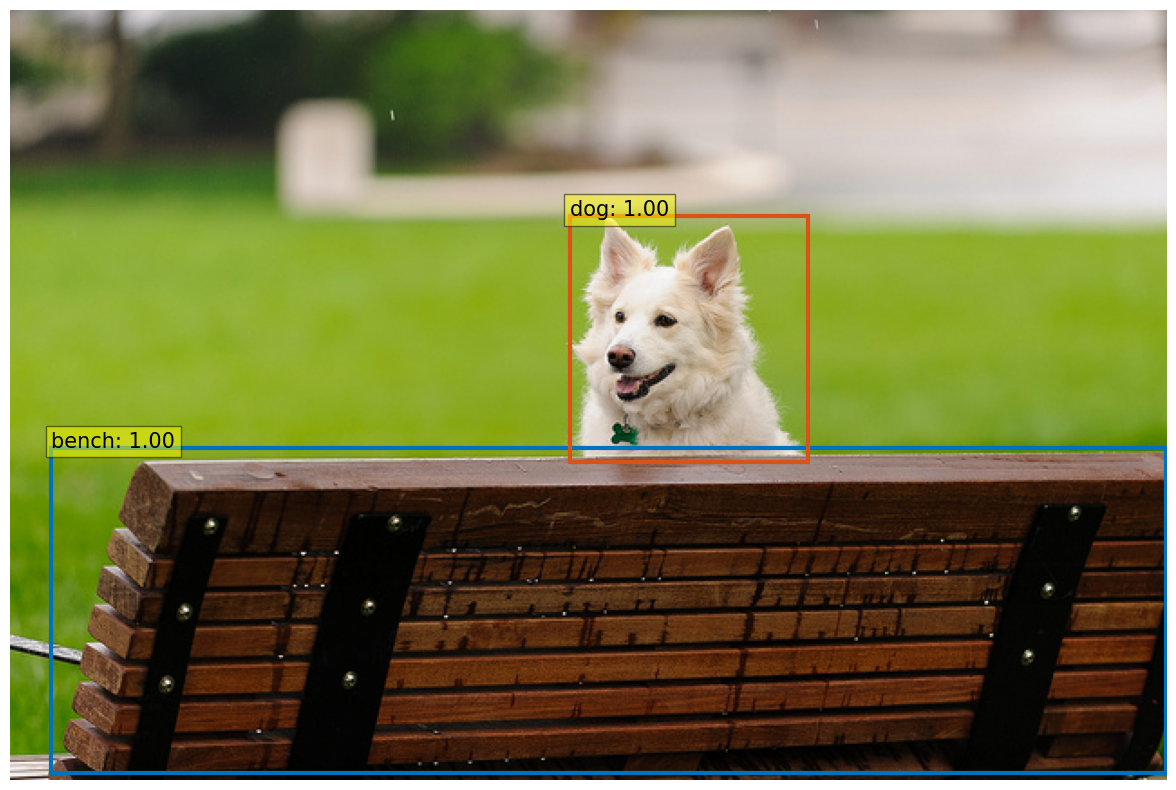

In [19]:
# plot output on image
probas = torch.tensor(outputs['pred_logits']).softmax(-1)[0, :, :-1]
keep = probas.max(-1).values > 0.9
bboxes_scaled = rescale_bboxes(torch.tensor(outputs['pred_boxes'][0, keep]), im.size)
plot_results(im, probas[keep], bboxes_scaled)